In [52]:
""" Read "Supplementary_table.xlsx" to analyze and graph."""
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import rcParams, font_manager
import matplotlib as mpl
from scipy.stats import mannwhitneyu



# Load data
file_path = "Supplementary_table3.xlsx" # DMSO is lower that Figure 3 (starts at 10 when figure 3 starts around 35)
# file_path = "Supplementary_table3_1.xlsx" # DMSO is higher than Figure 3 (starts around 45 when figure 3 starts around 35)
# file_path = "Supplementary_table3_2.xlsx" # DMSO is higher than Figure 3 (starts around 45 when figure 3 starts around 35) -> same data than above 
# file_path = "supplementary_table3_3.xlsx" # DMSO is lower than Figure 3 (starts at 10 when figure 3 starts around 35) -> same data than 1st one

data_full = pd.read_excel(file_path)

# Show table for structure
data_full

,Drugname,Time,Filename,aver_pbody_number,std_pbody_number,ROI_intensity,background_intensity,intensity (A. U),std_intensity (A. U),Plate
0,T1648,T1,W0014F0001T0001Z000C3.tif,21.086957,2.989036,150.247671,108.422915,41.824756,3.360654,1.0
1,T1648,T1,W0014F0002T0001Z000C3.tif,16.467890,NaN,148.597068,109.147567,39.449501,NaN,1.0
2,T1648,T1,W0014F0003T0001Z000C3.tif,15.490909,NaN,143.532850,108.340958,35.191891,NaN,1.0
3,T1297,T1,W0015F0001T0001Z000C3.tif,16.210526,2.438608,147.665168,108.603770,39.061398,3.632900,1.0
4,T1297,T1,W0015F0002T0001Z000C3.tif,20.585714,NaN,154.213913,108.740726,45.473187,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...
7147,TQ0319,T7,W0042F0002T0007Z000C3.tif,12.285714,NaN,127.070554,107.993671,19.076883,NaN,5.0
7148,TQ0319,T7,W0042F0003T0007Z000C3.tif,13.352941,NaN,126.677896,109.770349,16.907547,NaN,5.0
7149,TQ0319,T8,W0042F0001T0008Z000C3.tif,13.200000,1.151042,124.558673,110.346871,14.211802,2.232944,5.0
7150,TQ0319,T8,W0042F0002T0008Z000C3.tif,12.857143,NaN,126.636953,108.049902,18.587051,NaN,5.0


In [53]:
""" Whenver the Std_pbody_number column and Std_inrensiry (A. U) columns have NaN values, copy the values from the same column row above"""
data_full['std_pbody_number'].ffill(inplace=True)
data_full['std_intensity (A. U)'].ffill(inplace=True)
data_full

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/1574906052.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_full['std_pbody_number'].ffill(inplace=True)
/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/1574906052.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

,Drugname,Time,Filename,aver_pbody_number,std_pbody_number,ROI_intensity,background_intensity,intensity (A. U),std_intensity (A. U),Plate
0,T1648,T1,W0014F0001T0001Z000C3.tif,21.086957,2.989036,150.247671,108.422915,41.824756,3.360654,1.0
1,T1648,T1,W0014F0002T0001Z000C3.tif,16.467890,2.989036,148.597068,109.147567,39.449501,3.360654,1.0
2,T1648,T1,W0014F0003T0001Z000C3.tif,15.490909,2.989036,143.532850,108.340958,35.191891,3.360654,1.0
3,T1297,T1,W0015F0001T0001Z000C3.tif,16.210526,2.438608,147.665168,108.603770,39.061398,3.632900,1.0
4,T1297,T1,W0015F0002T0001Z000C3.tif,20.585714,2.438608,154.213913,108.740726,45.473187,3.632900,1.0
...,...,...,...,...,...,...,...,...,...,...
7147,TQ0319,T7,W0042F0002T0007Z000C3.tif,12.285714,1.079388,127.070554,107.993671,19.076883,1.404036,5.0
7148,TQ0319,T7,W0042F0003T0007Z000C3.tif,13.352941,1.079388,126.677896,109.770349,16.907547,1.404036,5.0
7149,TQ0319,T8,W0042F0001T0008Z000C3.tif,13.200000,1.151042,124.558673,110.346871,14.211802,2.232944,5.0
7150,TQ0319,T8,W0042F0002T0008Z000C3.tif,12.857143,1.151042,126.636953,108.049902,18.587051,2.232944,5.0


In [54]:
# print(data_full[data_full["Drugname"]=="DMSO"][["Time", "aver_pbody_number"]])

In [55]:
""" Filter data so that only "Time" T6 is shown """
data = data_full[data_full["Time"] == "T6"]
data.head()

,Drugname,Time,Filename,aver_pbody_number,std_pbody_number,ROI_intensity,background_intensity,intensity (A. U),std_intensity (A. U),Plate
885,T1648,T6,W0014F0001T0006Z000C3.tif,16.869565,2.281128,134.745747,109.780566,24.965180,1.871177,1.0
886,T1648,T6,W0014F0002T0006Z000C3.tif,12.504587,2.281128,133.768611,112.525042,21.243569,1.871177,1.0
887,T1648,T6,W0014F0003T0006Z000C3.tif,15.836364,2.281128,133.486623,110.041487,23.445136,1.871177,1.0
888,T1297,T6,W0015F0001T0006Z000C3.tif,11.631579,3.249588,133.226990,109.850472,23.376518,2.197952,1.0
889,T1297,T6,W0015F0002T0006Z000C3.tif,18.128571,3.249588,138.344190,110.603844,27.740346,2.197952,1.0


# Figure 1: # of Pbody Accross Time 

In [56]:
# --- FIX TIME COLUMN ---
data_full["Time"] = (
    data_full["Time"].astype(str).str.replace("T", "", regex=False).astype(float)
)

# --- AGGREGATE: mean + std per Drug per Time ---
agg = (
    data_full.groupby(["Drugname", "Time"])
    .agg(
        Aver_pbody_number=("aver_pbody_number", "mean"),
        Std_pbody_number=("aver_pbody_number", "std")   
    )
    .reset_index()
)

In [57]:
dms = agg[agg["Drugname"] == "DMSO"].sort_values("Time")

if dms.empty:
    raise ValueError("No DMSO data found.")


# --- FIX TIME COLUMN ---
data_full["Time"] = (
    data_full["Time"].astype(str).str.replace("T", "", regex=False).astype(float)
)

# --- AGGREGATE: MEAN + STD ---
agg = (
    data_full.groupby(["Drugname", "Time"])
    .agg(
        Aver_pbody_number=("aver_pbody_number", "mean"),
        Std_pbody_number=("aver_pbody_number", "std")
    )
    .reset_index()
)

# --- PRINT THE TABLE (sorted for readability) ---
agg_sorted = agg.sort_values(["Drugname", "Time"])
print("=== AGGREGATED TABLE: MEAN & STD PER DRUG PER TIME ===")
print(agg_sorted.to_string(index=False))


=== AGGREGATED TABLE: MEAN & STD PER DRUG PER TIME ===
Drugname  Time  Aver_pbody_number  Std_pbody_number
    DMSO   1.0          14.748561          3.015962
    DMSO   2.0          13.663174          2.477942
    DMSO   3.0          13.306358          2.577691
    DMSO   4.0          13.638743          3.088092
    DMSO   5.0          14.876014          2.548768
    DMSO   6.0          15.517389          2.240733
    DMSO   7.0          15.411123          2.842388
    DMSO   8.0          15.375360          2.558825
   MG132   1.0          11.722513          2.950533
   MG132   2.0          10.094242          2.250463
   MG132   3.0           9.585585          1.718109
   MG132   4.0           8.107048          1.916467
   MG132   5.0           7.193907          1.426520
   MG132   6.0           6.447809          1.540044
   MG132   7.0           6.405593          1.501956
   MG132   8.0           5.831072          2.046232
   T0030   1.0          15.745477          0.287168
   T0030 

In [58]:
# drugs_to_plot = ["T1995", "T6020", "T1829", "T2485", 
#                  "T6156", "T7503", "T6321", "T1929"]

# # Create 4×2 panel
# fig, axes = plt.subplots(4, 2, figsize=(10, 10))
# axes = axes.flatten()

# for i, drug in enumerate(drugs_to_plot):
#     ax = axes[i]
    
#     sub = agg[agg["Drugname"] == drug].sort_values("Time")
#     if sub.empty:
#         ax.text(0.5, 0.5, f"{drug}\n(no data)",
#                 ha="center", va="center", fontsize=12)
#         ax.axis("off")
#         continue

#     # --- DMSO curve (mean + STD) ---
#     ax.errorbar(
#         dms["Time"], dms["Aver_pbody_number"],
#         yerr=dms["Std_pbody_number"],
#         fmt="-o", color="#7ECBA4", label="DMSO"
#     )

#     # --- Drug curve (mean + STD) ---
#     ax.errorbar(
#         sub["Time"], sub["Aver_pbody_number"],
#         yerr=sub["Std_pbody_number"],
#         fmt="-o", color="#003366", label=drug
#     )

#     # Formatting
#     ax.set_title(drug, fontsize=14)
#     ax.set_xlabel("Time (hours)")
#     ax.set_ylabel("P-body number")

#     ax.set_ylim(0, 1.0 * agg["Aver_pbody_number"].max())
#     ax.set_xlim(agg["Time"].min() - 0.2, agg["Time"].max() + 0.2)

#     ax.legend(frameon=False, fontsize=10)

# # Turn off unused axes
# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.savefig("figure1_all_subplots.png", dpi=300)
# plt.show()


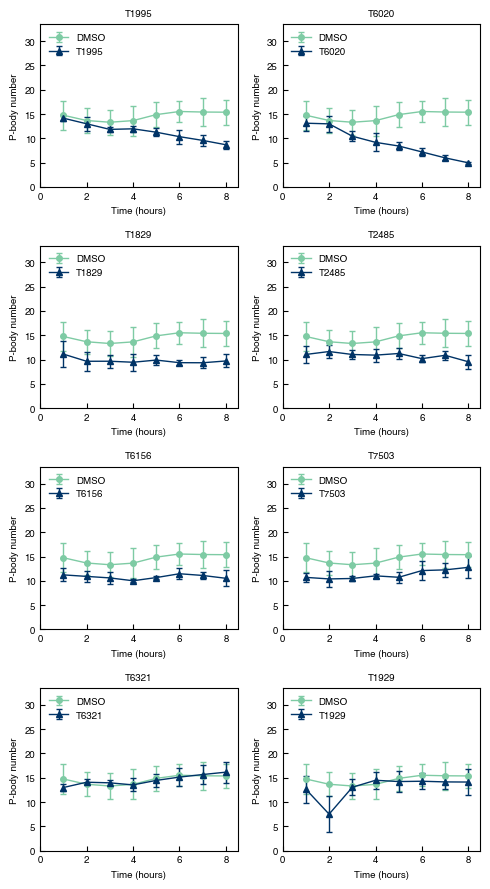

In [59]:
# Frontend config - Font 
mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 5

# Drugs to be plotted
drugs_to_plot = ["T1995", "T6020", "T1829", "T2485",
                 "T6156", "T7503", "T6321", "T1929"]

# Create big canvas
fig, axes = plt.subplots(4, 2, figsize=(5, 9))
axes = axes.flatten()

# Data aggregated
dms = agg[agg["Drugname"] == "DMSO"].sort_values("Time")

if dms.empty:
    raise ValueError("No DMSO data found!")

# Go over drugs
for i, drug in enumerate(drugs_to_plot):
    ax = axes[i]

    # Subset for drug
    sub = agg[agg["Drugname"] == drug].sort_values("Time")

    if sub.empty:
        ax.text(0.5, 0.5, f"{drug}\n(no data)",
                ha="center", va="center", fontsize=7)
        ax.axis("off")
        continue

    # PLOT DMSO (mean & STD)
    ax.errorbar(
        dms["Time"], dms["Aver_pbody_number"],
        yerr=dms["Std_pbody_number"],
        fmt="-o", color="#7ECBA4", markersize=4,
        linewidth=1, capsize=2, label="DMSO"
    )

    # PLOT DRUG (mean & STD) 
    ax.errorbar(
        sub["Time"], sub["Aver_pbody_number"],
        yerr=sub["Std_pbody_number"],
        fmt='^-',                       # makes it a triangle
        color="#003366", markersize=4,
        linewidth=1, capsize=2, label=drug
    )

    # "Front-end"
    ax.set_title(drug, fontsize=7)
    ax.set_xlabel("Time (hours)", fontsize=7)
    ax.set_ylabel("P-body number", fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

    # Start axes at (0,0)
    ax.set_ylim(0, agg["Aver_pbody_number"].max() * 1.05)
    ax.set_xlim(0, 8.5)     # for square layout
    ax.set_xticks([0, 2, 4, 6, 8])
    ax.tick_params(axis='both', direction='in', width=0.8)

    # Legend small and clean
    ax.legend(frameon=False, fontsize=7, loc="upper left")

# No-show for empty pannels
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig("figure1_all_subplots.png", dpi=450)
plt.savefig("figure1_all_subplots.pdf", transparent=True, bbox_inches='tight')
plt.show()


# Figure 2: Groups and Intensity/Pbody #

In [60]:
group_dict = {
    "G1": ["T0374","TD374L","T1912","T1995","T6020","T7394"],
    "G2": ["T0860","T1448","T1656","T2508","T2509","T3380"],
    "G3": ["T0801","T1829","T2485","T2677","T6156","T7503"],
    "G4": ["T1929","T4883","T1936","T5171","T2S0007","T5177",
           "T3211","T6321","T3269","T7486","T3603","T7861",
           "T3616","T8482"],
    "G5": ["T12594","T1791","T1791L","T2372","T6165","T6588",
           "T6758","T7604","T8387"]
}

In [61]:
data_full["Time"] = data_full["Time"].astype(str).str.replace("T","").astype(float)

In [62]:
# Calculate intensity ratio
data["Intensity_ratio"] = data["intensity (A. U)"] / data["aver_pbody_number"]

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/3433036585.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Intensity_ratio"] = data["intensity (A. U)"] / data["aver_pbody_number"]


In [63]:
# Helper function to separate by groups
def assign_group(drug):
    for g, items in group_dict.items():
        if drug in items:
            return g
    if drug == "DMSO":
        return "DMSO"
    return None  # ignore drugs not in groups

data["Group"] = data["Drugname"].apply(assign_group)
data = data[data["Group"].notna()]


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/479396348.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Group"] = data["Drugname"].apply(assign_group)


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/4003581226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


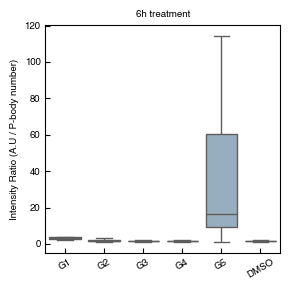

In [64]:
# ---- Set Helvetica globally ----
plt.rcParams["font.family"] = "Helvetica"

# ---- Desired Order ----
order = ["G1", "G2", "G3", "G4", "G5", "DMSO"]

fig2 = plt.figure(figsize=(3,3))

sns.boxplot(
    data=data,
    x="Group",
    y="Intensity_ratio",
    order=order,
    palette = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"],
    showfliers=False
)

# Labels and Title
plt.ylabel("Intensity Ratio (A.U / P-body number)", fontsize=7)
plt.xlabel("", fontsize=7)
plt.title("6h treatment", fontsize=7)

# Rotate ticks
plt.xticks(rotation=30, fontsize=7)
plt.yticks(fontsize=7)
plt.tick_params(direction='in')


plt.tight_layout()
plt.savefig("figure2_groups_boxplot.png", dpi=450)
plt.savefig("figure2_groups_boxplot.pdf", transparent=True, bbox_inches='tight')
plt.show()


/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/3209408389.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/3209408389.py:7: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(


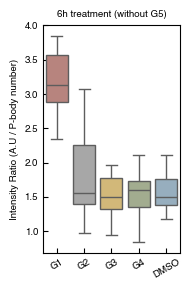

In [65]:
"""
    Plot 6h treatment again without group 5 for better visualization
"""
# Filter out Group 5
data_filtered = data[data["Group"] != "G5"]
plt.figure(figsize=(2,3))
sns.boxplot(
    data=data_filtered,
    x="Group",
    y="Intensity_ratio",
    order=["G1", "G2", "G3", "G4", "DMSO"],
    palette = ["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"],
    showfliers=False
)
# Labels and Title
plt.ylabel("Intensity Ratio (A.U / P-body number)", fontsize=7)
plt.xlabel("", fontsize=7)
plt.title("6h treatment (without G5)", fontsize=7)
# Rotate ticks
plt.xticks(rotation=30, fontsize=7)
plt.yticks(fontsize=7)
plt.tick_params(direction='in')
plt.tight_layout()
plt.savefig("figure2_groups_boxplot_noG5.png", dpi=450)
plt.show()

/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/1874857618.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qw/jg34zg4s36s3q9b0cy00dw4m0000gn/T/ipykernel_38964/1874857618.py:10: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(


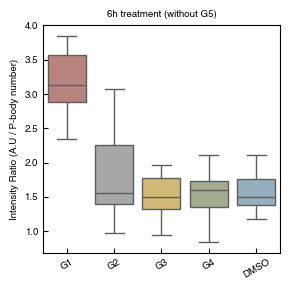

In [66]:
"""
    Plot 6h treatment again without group 5 for better visualization — square version
"""

# Filter out Group 5
data_filtered = data[data["Group"] != "G5"]

plt.figure(figsize=(3, 3))   # ← square shape

sns.boxplot(
    data=data_filtered,
    x="Group",
    y="Intensity_ratio",
    order=["G1", "G2", "G3", "G4", "DMSO"],
    palette=["#C17C74", "#A7A7A7", "#E1BE6A", "#A3B18A", "#90AFC5", "#B1A7DE"],
    showfliers=False
)

# Labels and Title
plt.ylabel("Intensity Ratio (A.U / P-body number)", fontsize=7)
plt.xlabel("", fontsize=7)
plt.title("6h treatment (without G5)", fontsize=7)

# Rotate ticks
plt.xticks(rotation=30, fontsize=7)
plt.tick_params(direction='in')
plt.yticks(fontsize=7)

plt.tight_layout()
plt.savefig("figure2_groups_boxplot_noG5_square.png", dpi=450)
plt.savefig("figure2_groups_boxplot_noG5_square.pdf", transparent=True, bbox_inches='tight')
plt.show()


In [67]:
"""
    Statistically Compare using Mann-Whitney U test the Intensity_ratio between each group (G1 to G5) and DMSO.
"""
results = []
for group in ["G1", "G2", "G3", "G4", "G5"]:
    group_data = data[data["Group"] == group]["Intensity_ratio"]
    dms_data = data[data["Group"] == "DMSO"]["Intensity_ratio"]
    
    stat, p_value = mannwhitneyu(group_data, dms_data, alternative='two-sided')
    
    results.append({
        "Group": group,
        "Mann-Whitney U Statistic": stat,
        "p-value": p_value
    })
# Display results
results_df = pd.DataFrame(results)
print("=== MANN-WHITNEY U TEST RESULTS ===")
results_df

=== MANN-WHITNEY U TEST RESULTS ===


,Group,Mann-Whitney U Statistic,p-value
0,G1,220.0,9.073401e-06
1,G2,160.0,3.757256e-01
2,G3,126.0,7.586012e-01
3,G4,313.0,9.783138e-01
4,G5,390.0,9.128985e-07


In [68]:
"""
    Create function to download all figures as pdf based on their saved filename on plt
"""
def save_figure_as_pdf(figure_filename, pdf_filename):
    """ Save a figure as PDF.
    
    Args:
        figure_filename (str): The filename of the figure to load (e.g., PNG).
        pdf_filename (str): The desired PDF filename to save.
    """
    from matplotlib.backends.backend_pdf import PdfPages
    from PIL import Image

    # Load the image
    img = Image.open(figure_filename)

    # Create a PDF
    with PdfPages(pdf_filename) as pdf:
        fig, ax = plt.subplots(figsize=(img.width / 100, img.height / 100), dpi=100)
        ax.imshow(img)
        ax.axis('off')  # No axes for image
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)
        
# Calling function to save plots:
# save_figure_as_pdf("figure1_all_subplots.png", "figure1_all_subplots.pdf")
# save_figure_as_pdf("figure2_groups_boxplot.png", "figure2_groups_boxplot.pdf")
# save_figure_as_pdf("figure2_groups_boxplot_noG5.png", "figure2_groups_boxplot_noG5.pdf")
# save_figure_as_pdf("figure2_groups_boxplot_noG5_square.png", "figure2_groups_boxplot_noG5_square.pdf")